In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML

base_folder = "../"

## Topologies

In [2]:
def read_topology(topology_name):
    print(f"Topology name: {topology_name}")
    df = pd.read_csv(f"{base_folder}/resources/env/{topology_name}.txt", delimiter=";")
    display(HTML(df.to_html()))
        
read_topology("multi")
read_topology("single")

Topology name: multi


,ClusterID,ClusterName,Cores,Speed,Memory,numberOfHosts,memoryCapacityPerHost,coreCountPerHost
0,A01,A01,32,3.20,2048,1,256,32
1,B01,B01,48,2.93,1256,6,64,8
2,C01,C01,32,3.20,2048,2,128,16


Topology name: single


,ClusterID,ClusterName,Cores,Speed,Memory,numberOfHosts,memoryCapacityPerHost,coreCountPerHost
0,A01,A01,8,3.2,128,1,128,8


## Traces

In [3]:
df_trace = pd.read_parquet(f"{base_folder}/resources/bitbrains-small/trace/trace.parquet")
df_trace.head()

,id,timestamp,duration,cpu_count,cpu_usage
0,1019,2013-08-12 13:40:46+00:00,300000,1,0.000000
1,1019,2013-08-12 13:45:46+00:00,300000,1,11.703998
2,1019,2013-08-12 13:55:46+00:00,600000,1,0.000000
3,1019,2013-08-12 14:00:46+00:00,300000,1,11.703998
4,1019,2013-08-12 14:15:46+00:00,900000,1,0.000000


In [4]:
df_meta = pd.read_parquet(f"{base_folder}/resources/bitbrains-small/trace/meta.parquet")
df_meta.head()

,id,start_time,stop_time,cpu_count,cpu_capacity,mem_capacity
0,1019,2013-08-12 13:35:46+00:00,2013-09-11 13:39:58+00:00,1,2926.000135,181352
1,1023,2013-08-12 13:35:46+00:00,2013-09-11 13:39:58+00:00,1,2925.999560,260096
2,1026,2013-08-12 13:35:46+00:00,2013-09-11 13:39:58+00:00,1,2925.999717,249972
3,1052,2013-08-29 14:38:12+00:00,2013-09-05 07:09:07+00:00,1,2926.000107,131245
4,1073,2013-08-21 11:07:12+00:00,2013-09-11 13:39:58+00:00,1,2599.999649,179306


# Lets run this in OpenDC!

## Resulting Files

In [5]:
output_folder = f"{base_folder}/output"
workload = "workload=bitbrains-small"
seed = "seed=0"

df_host_single = pd.read_parquet(f"{output_folder}/host/topology=single/{workload}/{seed}/data.parquet")
df_host_multi = pd.read_parquet(f"{output_folder}/host/topology=multi/{workload}/{seed}/data.parquet")

df_server_single = pd.read_parquet(f"{output_folder}/server/topology=single/{workload}/{seed}/data.parquet")
df_server_multi = pd.read_parquet(f"{output_folder}/server/topology=multi/{workload}/{seed}/data.parquet")

df_service_single = pd.read_parquet(f"{output_folder}/service/topology=single/{workload}/{seed}/data.parquet")
df_service_multi = pd.read_parquet(f"{output_folder}/service/topology=multi/{workload}/{seed}/data.parquet")

def add_absolute_timestamp(df, start_dt):
    df["absolute_timestamp"] = start_dt + (df["timestamp"] - df["timestamp"].min())

add_absolute_timestamp(df_host_single, df_meta["start_time"].min())
add_absolute_timestamp(df_host_single, df_meta["start_time"].min())

add_absolute_timestamp(df_server_single, df_meta["start_time"].min())
add_absolute_timestamp(df_server_multi, df_meta["start_time"].min())

add_absolute_timestamp(df_service_single, df_meta["start_time"].min())
add_absolute_timestamp(df_service_multi, df_meta["start_time"].min())

## Service

In [35]:
df_service_single.head()

,timestamp,hosts_up,hosts_down,servers_pending,servers_active,attempts_success,attempts_failure,attempts_error,absolute_timestamp
0,1970-01-01 00:05:00+00:00,1,0,29,15,15,0,0,2013-08-12 13:35:46+00:00
1,1970-01-01 00:10:00+00:00,1,0,29,15,15,0,0,2013-08-12 13:40:46+00:00
2,1970-01-01 00:15:00+00:00,1,0,29,15,15,0,0,2013-08-12 13:45:46+00:00
3,1970-01-01 00:20:00+00:00,1,0,29,15,15,0,0,2013-08-12 13:50:46+00:00
4,1970-01-01 00:25:00+00:00,1,0,29,15,15,0,0,2013-08-12 13:55:46+00:00


In [37]:
print(f"The single cluster topology has {len(df_service_single)} samples in the service file")
print(f"The multi cluster topology has  {len(df_service_multi)} samples in the service file")

The single cluster topology has 25922 samples in the service file
The multi cluster topology has  8641 samples in the service file


## Server

In [38]:
df_server_single.head()

,timestamp,server_id,server_name,host_id,mem_capacity,cpu_count,cpu_limit,cpu_time_active,cpu_time_idle,cpu_time_steal,cpu_time_lost,uptime,downtime,provision_time,boot_time,absolute_timestamp
0,1970-01-01 00:05:00+00:00,00000000-0000-0000-06c4-5d188009454f,1019,e220a839-7b1d-cdaf-0000-000000000000,181,1,25600.0,0,2624,0,0,300000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2013-08-12 13:35:46+00:00
1,1970-01-01 00:05:00+00:00,00000000-0000-0000-1b39-896a51a8749b,1023,e220a839-7b1d-cdaf-0000-000000000000,260,1,25600.0,0,2624,0,0,300000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2013-08-12 13:35:46+00:00
2,1970-01-01 00:05:00+00:00,00000000-0000-0000-2c82-9abe1f4532e1,1026,e220a839-7b1d-cdaf-0000-000000000000,250,1,25600.0,2,2622,0,0,300000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2013-08-12 13:35:46+00:00
3,1970-01-01 00:05:00+00:00,00000000-0000-0000-3ee5-789041c98ac3,1129,e220a839-7b1d-cdaf-0000-000000000000,125,1,25600.0,0,2624,0,0,300000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2013-08-12 13:35:46+00:00
4,1970-01-01 00:05:00+00:00,00000000-0000-0000-657e-ecdd3cb13d09,1138,e220a839-7b1d-cdaf-0000-000000000000,157,1,25600.0,2,2951,0,0,300000,0,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2013-08-12 13:35:46+00:00


In [39]:
print(f"The single cluster topology has {len(df_server_single)} samples in the server file")
print(f"The multi cluster topology has  {len(df_server_multi)} samples in the server file")

The single cluster topology has 812315 samples in the server file
The multi cluster topology has  404330 samples in the server file


## Host

In [41]:
df_host_single.head()

,timestamp,host_id,cpu_count,mem_capacity,guests_terminated,guests_running,guests_error,guests_invalid,cpu_limit,cpu_usage,...,cpu_utilization,cpu_time_active,cpu_time_idle,cpu_time_steal,cpu_time_lost,power_total,uptime,downtime,boot_time,absolute_timestamp
0,1970-01-01 00:05:00+00:00,e220a839-7b1d-cdaf-0000-000000000000,8,128000,0,15,0,0,25600.0,25600.000000,...,1.000000,2400,0,550,0,105000.000000,300000,0,1970-01-01 00:00:00+00:00,2013-08-12 13:35:46+00:00
1,1970-01-01 00:10:00+00:00,e220a839-7b1d-cdaf-0000-000000000000,8,128000,0,15,0,0,25600.0,25600.000000,...,1.000000,2400,0,272,0,105000.000000,300000,0,1970-01-01 00:00:00+00:00,2013-08-12 13:40:46+00:00
2,1970-01-01 00:15:00+00:00,e220a839-7b1d-cdaf-0000-000000000000,8,128000,0,15,0,0,25600.0,25600.000000,...,1.000000,2400,0,186,0,105000.000000,300000,0,1970-01-01 00:00:00+00:00,2013-08-12 13:45:46+00:00
3,1970-01-01 00:20:00+00:00,e220a839-7b1d-cdaf-0000-000000000000,8,128000,0,15,0,0,25600.0,15663.784180,...,0.611867,1468,931,0,0,87533.995628,300000,0,1970-01-01 00:00:00+00:00,2013-08-12 13:50:46+00:00
4,1970-01-01 00:25:00+00:00,e220a839-7b1d-cdaf-0000-000000000000,8,128000,0,15,0,0,25600.0,16637.050781,...,0.649885,1560,840,0,0,89244.815826,300000,0,1970-01-01 00:00:00+00:00,2013-08-12 13:55:46+00:00


In [42]:
print(f"The single cluster topology has {len(df_host_single)} samples in the host file")
print(f"The multi cluster topology has  {len(df_host_multi)} samples in the host file")

The single cluster topology has 25922 samples in the host file
The multi cluster topology has  77769 samples in the host file


# Analysis

## Power Usage

In [69]:
print(f"single topology:  {df_host_single.power_total.sum():.3f} Wh")
print(f"multi topology:   {df_host_multi.power_total.sum():.3f} Wh")

single topology:  2227253755.278 Wh
multi topology:   5864872551.732 Wh


## CPU utilization

In [70]:
print(f"single topology:  {df_host_single.cpu_utilization.mean()*100:.2f}%")
print(f"multi topology:   {df_host_multi.cpu_utilization.mean()*100:.2f}%")

single topology:  57.61%
multi topology:   34.25%


# Plotting Results

## CPU utility

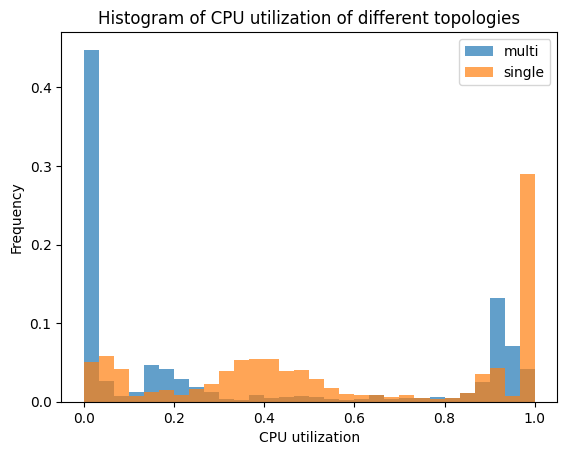

In [46]:
data = df_host_multi.cpu_utilization
plt.hist(data, weights=np.ones_like(data) / len(data),
         alpha=0.7, label="multi", bins=30)


data = df_host_single.cpu_utilization
plt.hist(data, weights=np.ones_like(data) / len(data),
         alpha=0.7, label="single", bins=30)

plt.title("Histogram of CPU utilization of different topologies")
plt.xlabel("CPU utilization")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Active Servers

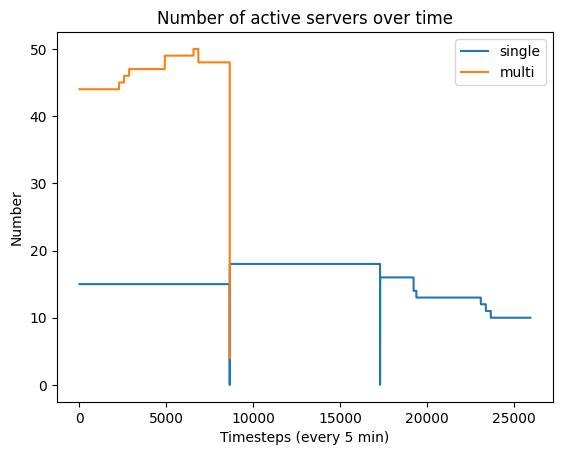

In [51]:
plt.plot(df_service_single.servers_active, label="single")
plt.plot(df_service_multi.servers_active, label="multi")

plt.title("Number of active servers over time")
plt.ylabel("Number")
plt.xlabel("Timesteps (every 5 min)")

plt.legend()
plt.show()

# Additional plots (extra content)

## Running average

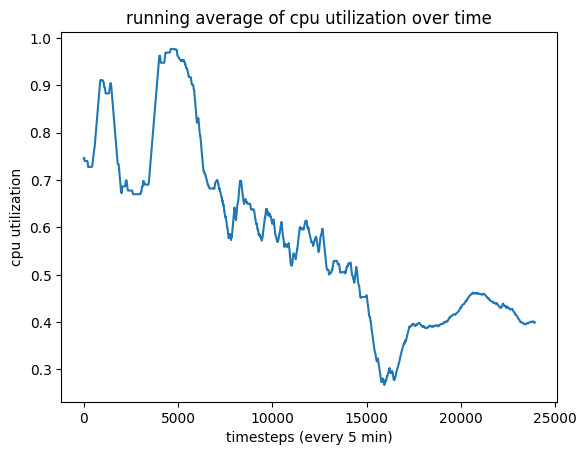

In [53]:
def get_running_avg(data, window):
    res = []

    for ind in range(len(data) - window + 1):
        res.append(np.mean(utilization[ind:ind+window]))
    
    return res

utilization = df_host_single.cpu_utilization.to_numpy()

avg_utilization = get_running_avg(utilization, 2000)
plt.plot(avg_utilization)

plt.title("running average of cpu utilization over time")
plt.xlabel("timesteps (every 5 min)")
plt.ylabel("cpu utilization")

plt.show()

## Comparing hosts

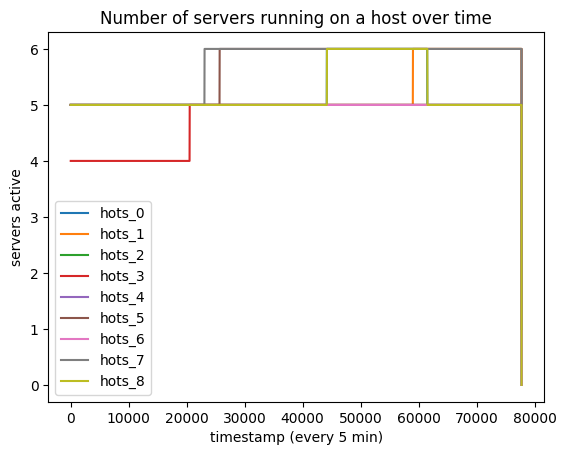

In [63]:
for i, (g,s) in enumerate(df_host_multi.groupby("host_id")):
    plt.plot(s.guests_running, label=f"hots_{i}")

plt.title("Number of servers running on a host over time")
plt.xlabel("timestamp (every 5 min)")
plt.ylabel("servers active")
plt.legend()
plt.show()